In [2]:
import Pkg; Pkg.activate("/Users/heerakbanerjee/Documents/Newtrinos.jl/devenv/")

  Activating project at `~/Documents/Newtrinos.jl/devenv`


In [1]:
#using Revise
using Newtrinos
using Plots

**Test coherent_lar**

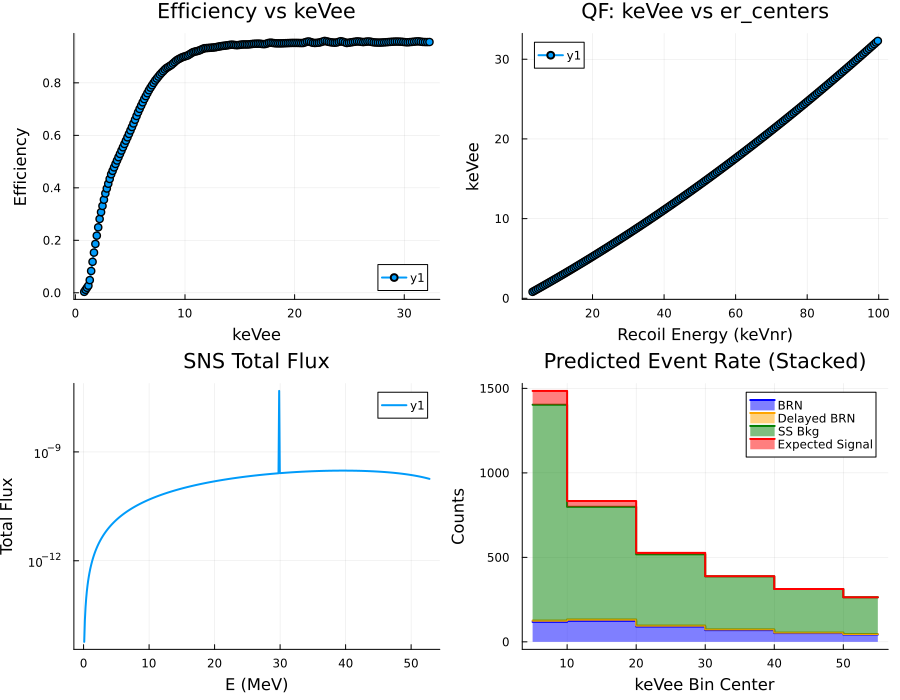

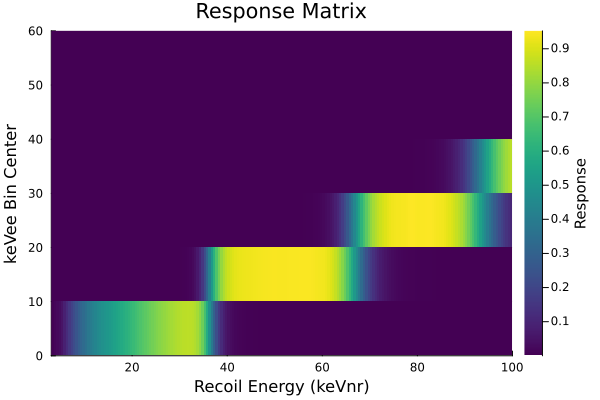

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:68


Total expected signal counts: 125.68390153573714
Total BRN background counts: 497.00000000000006
Total Delayed BRN background counts: 33.0
Total SS background counts: 3154.0


In [2]:
physics = (sns_flux = Newtrinos.sns_flux.configure(),)
e = Newtrinos.coherent_lAr.configure(physics)
p = Newtrinos.get_params(e)

er_centers = e.assets.er_centers
keVee = Newtrinos.coherent_lAr.qf(er_centers, p)
eff_vals = Newtrinos.coherent_lAr.eff(keVee, e.assets)

flux_result = e.physics.sns_flux.flux(exposure=e.assets.exposure, distance=e.assets.distance)
E = flux_result.E
flux_total = flux_result.total_flux

expected_counts = Newtrinos.coherent_lAr.get_expected(p, e.physics, e.assets)
out_centers = e.assets.out_centers

# Backgrounds
bkg_brn, bkg_delbrn, bkg_ss_bkg = Newtrinos.coherent_lAr.get_backgrounds(p, e.assets)
# Compute cumulative components
bkg_brn_cum = bkg_brn
bkg_delbrn_cum = bkg_brn .+ bkg_delbrn
bkg_ss_bkg_cum = bkg_brn .+ bkg_delbrn .+ bkg_ss_bkg
signal_cum = bkg_brn .+ bkg_delbrn .+ bkg_ss_bkg .+ expected_counts

# Define the first three plots
plt1 = plot(keVee, eff_vals, xlabel="keVee", ylabel="Efficiency", title="Efficiency vs keVee", lw=2, marker=:circle)
plt2 = plot(er_centers, keVee, xlabel="Recoil Energy (keVnr)", ylabel="keVee", title="QF: keVee vs er_centers", lw=2, marker=:circle)
plt3 = plot(E, flux_total, xlabel="E (MeV)", ylabel="Total Flux", title="SNS Total Flux", lw=2, yscale=:log10)

# Stacked rate plot
plt4 = plot(out_centers, bkg_brn_cum, label="BRN", seriestype=:stepmid, lw=2, fillrange=0, fillalpha=0.5, color=:blue)
plot!(out_centers, bkg_delbrn_cum, label="Delayed BRN", seriestype=:stepmid, lw=2, fillrange=bkg_brn_cum, fillalpha=0.5, color=:orange)
plot!(out_centers, bkg_ss_bkg_cum, label="SS Bkg", seriestype=:stepmid, lw=2, fillrange=bkg_delbrn_cum, fillalpha=0.5, color=:green)
plot!(out_centers, signal_cum, label="Expected Signal", seriestype=:stepmid, lw=2, fillrange=bkg_ss_bkg_cum, fillalpha=0.5, color=:red)
plot!(xlabel="keVee Bin Center", ylabel="Counts", title="Predicted Event Rate (Stacked)", legend=:topright)
plt4 = current()

plot(plt1, plt2, plt3, plt4, layout=(2,2), size=(900,700))
display(current())

# Response matrix plot
response_matrix = Newtrinos.coherent_lAr.construct_response_matrix(p, e.assets)
heatmap(er_centers, out_centers, response_matrix,
    xlabel="Recoil Energy (keVnr)",
    ylabel="keVee Bin Center",
    title="Response Matrix",
    colorbar_title="Response",
    c=:viridis,
    clims=(maximum([minimum(response_matrix[response_matrix .> 0]), 1e-10]), maximum(response_matrix)),
    colorbar=true)
display(current())

println("Total expected signal counts: ", sum(expected_counts))
println("Total BRN background counts: ", sum(bkg_brn))
println("Total Delayed BRN background counts: ", sum(bkg_delbrn))
println("Total SS background counts: ", sum(bkg_ss_bkg))

**Test coherent_csi**

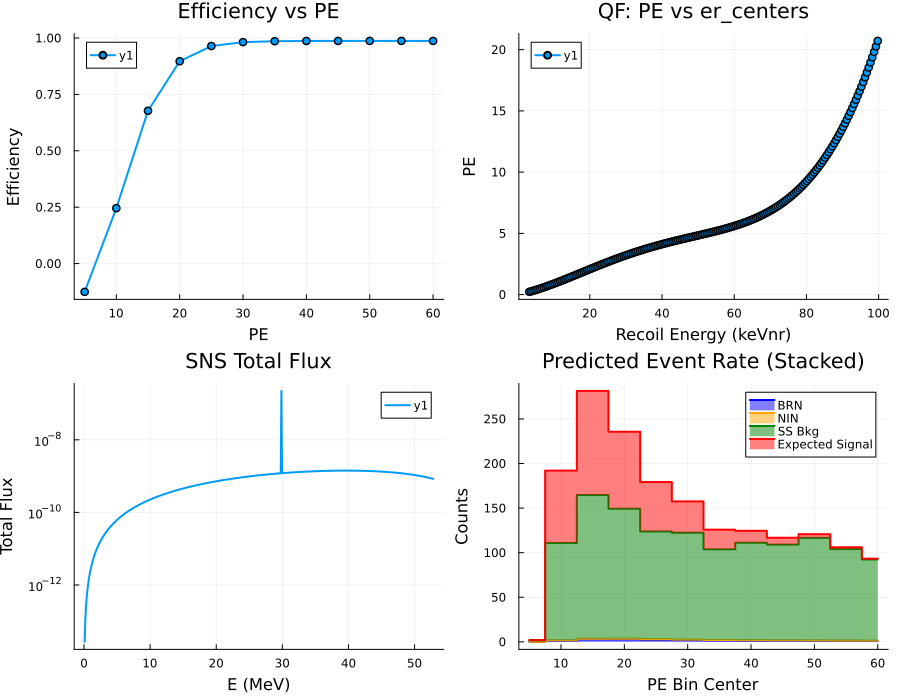

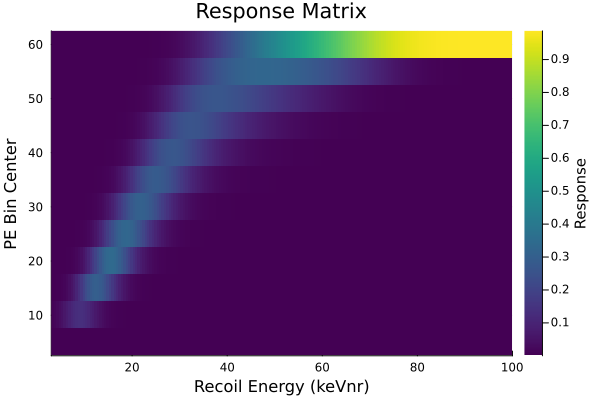

┌ Info: Loading coherent csi data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:77


Total expected signal counts: 425.019449788068
Total BRN background counts: 18.4
Total NIN background counts: 5.6000000000000005
Total SS background counts: 1286.0


In [3]:
physics = (sns_flux = Newtrinos.sns_flux.configure(),)
e = Newtrinos.coherent_csi.configure(physics)
p = Newtrinos.get_params(e)

er_centers = e.assets.er_centers
pe_centers = e.assets.out_centers

# Efficiency and QF (if available)
eff_vals = Newtrinos.coherent_csi.eff(pe_centers, e.params)
qf_vals = Newtrinos.coherent_csi.qf(er_centers, p)

flux_result = e.physics.sns_flux.flux(exposure=e.assets.exposure, distance=e.assets.distance)
E = flux_result.E
flux_total = flux_result.total_flux

expected_counts = Newtrinos.coherent_csi.get_expected(p, e.physics, e.assets)

# Backgrounds
bkg_brnPE, bkg_ninPE, bkg_ssBkg = Newtrinos.coherent_csi.get_backgrounds(p, e.assets)

# Compute cumulative components for stacked plot
bkg_brnPE_cum = bkg_brnPE
bkg_ninPE_cum = bkg_brnPE .+ bkg_ninPE
bkg_ssBkg_cum = bkg_brnPE .+ bkg_ninPE .+ bkg_ssBkg
signal_cum = bkg_brnPE .+ bkg_ninPE .+ bkg_ssBkg .+ expected_counts

# Define the first three plots
plt1 = plot(pe_centers, eff_vals, xlabel="PE", ylabel="Efficiency", title="Efficiency vs PE", lw=2, marker=:circle)
plt2 = plot(er_centers, qf_vals, xlabel="Recoil Energy (keVnr)", ylabel="PE", title="QF: PE vs er_centers", lw=2, marker=:circle)
plt3 = plot(E, flux_total, xlabel="E (MeV)", ylabel="Total Flux", title="SNS Total Flux", lw=2, yscale=:log10)

# Stacked rate plot
plt4 = plot(pe_centers, bkg_brnPE_cum, label="BRN", seriestype=:stepmid, lw=2, fillrange=0, fillalpha=0.5, color=:blue)
plot!(pe_centers, bkg_ninPE_cum, label="NIN", seriestype=:stepmid, lw=2, fillrange=bkg_brnPE_cum, fillalpha=0.5, color=:orange)
plot!(pe_centers, bkg_ssBkg_cum, label="SS Bkg", seriestype=:stepmid, lw=2, fillrange=bkg_ninPE_cum, fillalpha=0.5, color=:green)
plot!(pe_centers, signal_cum, label="Expected Signal", seriestype=:stepmid, lw=2, fillrange=bkg_ssBkg_cum, fillalpha=0.5, color=:red)
plot!(xlabel="PE Bin Center", ylabel="Counts", title="Predicted Event Rate (Stacked)", legend=:topright)
plt4 = current()

plot(plt1, plt2, plt3, plt4, layout=(2,2), size=(900,700))
display(current())

# Response matrix plot
response_matrix = Newtrinos.coherent_csi.construct_response_matrix(p, e.assets)
heatmap(er_centers, pe_centers, response_matrix,
    xlabel="Recoil Energy (keVnr)",
    ylabel="PE Bin Center",
    title="Response Matrix",
    colorbar_title="Response",
    c=:viridis,
    clims=(maximum([minimum(response_matrix[response_matrix .> 0]), 1e-10]), maximum(response_matrix)),
    colorbar=true)
display(current())

println("Total expected signal counts: ", sum(expected_counts))
println("Total BRN background counts: ", sum(bkg_brnPE))
println("Total NIN background counts: ", sum(bkg_ninPE))
println("Total SS background counts: ", sum(bkg_ssBkg))